# Video 4a - QSAR Data Preparation
**AI for Drug Discovery series**
Author: Sreenivas Bhattiprolu (DigitalSreeni)
YouTube: [youtube.com/@DigitalSreeni](https://www.youtube.com/@DigitalSreeni)
GitHub: [github.com/bnsreenu](https://github.com/bnsreenu)

---

## What this notebook covers

This is a standalone data preparation notebook for QSAR modeling. It pulls
EGFR inhibitor data directly from ChEMBL, processes it, applies a stratified
Murcko scaffold split, and saves a clean dataset for modeling in Video 4b.

This notebook does not depend on the CSV from Video 3 - it fetches its own
data so it can be run independently.

**Steps:**
1. Pull full EGFR IC50 dataset from ChEMBL
2. Deduplicate - geometric mean IC50 per compound
3. Log-transform IC50 values
4. Define active vs inactive labels
5. Compute Morgan fingerprints and physicochemical descriptors
6. Apply a stratified Murcko scaffold split
7. Save processed data to Drive for Video 4b

**Environment:** Google Colab (CPU only)

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Install and import libraries

In [ ]:
!pip install rdkit chembl-webresource-client -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import display
import os

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

from chembl_webresource_client.new_client import new_client

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        120,
})

print('All libraries imported.')

All libraries imported.


## 3. Set output paths

In [ ]:
OUTPUT_DIR = (
    '/content/drive/MyDrive/ColabNotebooks/'
    'AI_for_drug_discovery/Video4_qsar_modeling/data/'
)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output directory: {OUTPUT_DIR}')

Output directory: /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video4_qsar_modeling/data/


## 4. Pull full EGFR IC50 dataset from ChEMBL

We query ChEMBL for all IC50 measurements against EGFR (CHEMBL203) in
nanomolar units. We set limit of records to about 10000 (can be changed).

This replaces the limited 500-record pull from Video 3 and makes this
notebook fully standalone.

In [ ]:
RAW_CSV = OUTPUT_DIR + 'egfr_raw_chembl.csv'

if os.path.exists(RAW_CSV):
    print('Loading saved ChEMBL data...')
    df_raw = pd.read_csv(RAW_CSV)
    print(f'Loaded {len(df_raw)} records from cache.')
else:
    print('Querying ChEMBL (this may take a minute)...')
    activity = new_client.activity
    egfr_raw = list(activity.filter(
        target_chembl_id         = 'CHEMBL203',
        standard_type            = 'IC50',
        standard_units           = 'nM',
        standard_relation        = '=',
        assay_confidence_score   = 9,
        pchembl_value__isnull    = False,
        canonical_smiles__isnull = False,
    ).only([
        'molecule_chembl_id',
        'canonical_smiles',
        'standard_value',
        'standard_units',
    ])[:10000])

    df_raw = pd.DataFrame(egfr_raw)
    df_raw['standard_value'] = pd.to_numeric(
        df_raw['standard_value'], errors='coerce')
    df_raw = df_raw.rename(columns={'standard_value': 'IC50_nM'})
    df_raw = df_raw.dropna(subset=['canonical_smiles', 'IC50_nM'])
    df_raw = df_raw[df_raw['IC50_nM'] > 0]
    df_raw.to_csv(RAW_CSV, index=False)
    print(f'Query complete. {len(df_raw)} records saved to {RAW_CSV}')

print(f'Unique compounds: {df_raw["molecule_chembl_id"].nunique()}')
df_raw.head()

Loading saved ChEMBL data...
Loaded 10000 records from cache.
Unique compounds: 6306


,canonical_smiles,molecule_chembl_id,standard_units,IC50_nM,units,value
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,41.0,uM,0.041
1,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,300.0,uM,0.300
2,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,7820.0,uM,7.820
3,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,nM,170.0,uM,0.170
4,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,nM,40.0,uM,0.040


In [ ]:
# Save raw ChEMBL pull so we never need to query again
RAW_CSV = OUTPUT_DIR + 'egfr_raw_chembl.csv'
df_raw.to_csv(RAW_CSV, index=False)
print(f'Raw data saved: {RAW_CSV}  ({len(df_raw)} records)')

Raw data saved: /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video4_qsar_modeling/data/egfr_raw_chembl.csv  (10000 records)


## 5. Deduplicate - geometric mean IC50 per compound

The same compound can appear multiple times across different assays.
We take the geometric mean IC50 per compound. The geometric mean is
more appropriate than the arithmetic mean for potency data because
IC50 values span many orders of magnitude - it operates on the log
scale and is not skewed by extreme outliers.

In [ ]:
def geometric_mean_ic50(values):
    """Geometric mean of a list of positive IC50 values."""
    vals = [v for v in values if v > 0]
    if not vals:
        return np.nan
    return float(np.exp(np.mean(np.log(vals))))


df_dedup = (
    df_raw
    .groupby('molecule_chembl_id')
    .agg(
        canonical_smiles=('canonical_smiles', 'first'),
        IC50_nM_list    =('IC50_nM', list),
    )
    .reset_index()
)

df_dedup['IC50_nM'] = df_dedup['IC50_nM_list'].apply(geometric_mean_ic50)
df_dedup = df_dedup.drop(columns='IC50_nM_list')
df_dedup = df_dedup.dropna(subset=['IC50_nM'])

print(f'After deduplication: {len(df_dedup)} unique compounds')
print(f'IC50 range: {df_dedup["IC50_nM"].min():.2f} - {df_dedup["IC50_nM"].max():.0f} nM')

After deduplication: 6306 unique compounds
IC50 range: 0.01 - 100000 nM


## 6. Validate SMILES and compute molecular features

We convert each SMILES string to an RDKit molecule object, drop any
that fail, then compute:
- 8 physicochemical descriptors (MW, LogP, HBD, HBA, RotB, TPSA, Rings, ArRings)
- 1024-bit Morgan fingerprint (ECFP4, radius=2)

In [ ]:
def compute_descriptors(mol):
    """Compute a standard set of physicochemical descriptors."""
    return {
        'MW':      round(Descriptors.MolWt(mol), 2),
        'LogP':    round(Descriptors.MolLogP(mol), 2),
        'HBD':     rdMolDescriptors.CalcNumHBD(mol),
        'HBA':     rdMolDescriptors.CalcNumHBA(mol),
        'RotB':    rdMolDescriptors.CalcNumRotatableBonds(mol),
        'TPSA':    round(rdMolDescriptors.CalcTPSA(mol), 2),
        'Rings':   rdMolDescriptors.CalcNumRings(mol),
        'ArRings': rdMolDescriptors.CalcNumAromaticRings(mol),
    }


def morgan_fp(mol, radius=2, n_bits=1024):
    """ECFP4 Morgan fingerprint as a numpy uint8 array."""
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp  = gen.GetFingerprint(mol)
    arr = np.zeros(n_bits, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


# Parse SMILES
df_dedup['mol'] = df_dedup['canonical_smiles'].apply(Chem.MolFromSmiles)
n_before = len(df_dedup)
df_dedup = df_dedup[df_dedup['mol'].notna()].copy()
print(f'Valid structures: {len(df_dedup)} / {n_before}')

# Descriptors
print('Computing descriptors...')
desc_rows = [compute_descriptors(mol) for mol in df_dedup['mol']]
desc_df   = pd.DataFrame(desc_rows, index=df_dedup.index)
for col in desc_df.columns:
    df_dedup[col] = desc_df[col]

# Fingerprints
print('Computing Morgan fingerprints...')
fp_arrays = np.vstack([morgan_fp(mol) for mol in df_dedup['mol']])
print(f'Fingerprint matrix: {fp_arrays.shape}')
print('Done.')

Valid structures: 6306 / 6306
Computing descriptors...
Computing Morgan fingerprints...
Fingerprint matrix: (6306, 1024)
Done.


## 7. Log-transform IC50 and define activity labels

**Log transform:** IC50 values span many orders of magnitude. Taking log10
compresses the range and makes the distribution approximately symmetric,
which is much friendlier for regression models.

**Activity threshold:** IC50 <= 1000 nM is a common cutoff for EGFR in
the literature. Compounds below this are considered active leads.

Total compounds: 6306
Active   (IC50 <= 1000 nM): 4220  (66.9%)
Inactive (IC50 >  1000 nM): 2086 (33.1%)



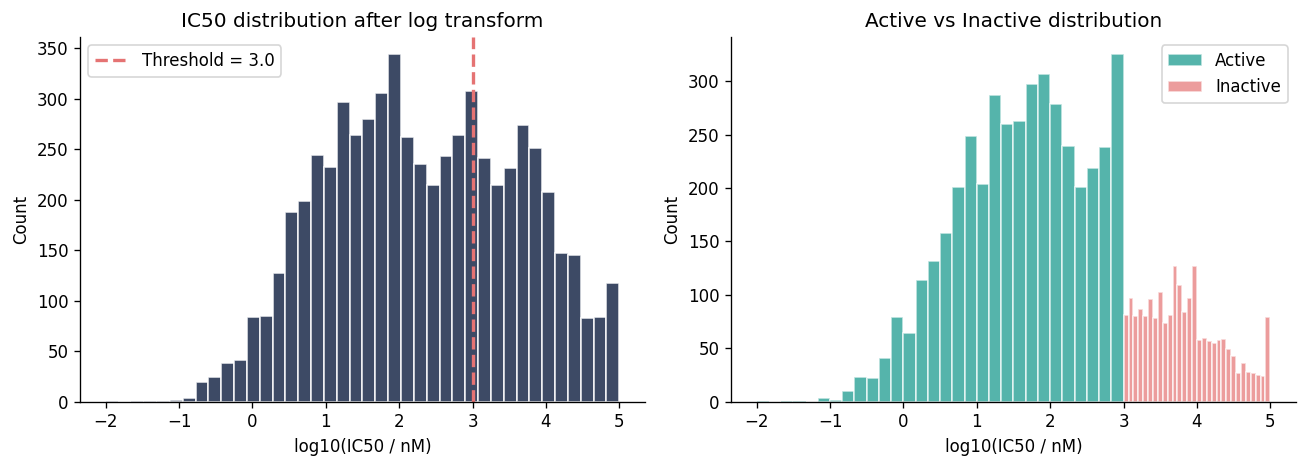

In [ ]:
df_dedup['log_IC50'] = np.log10(df_dedup['IC50_nM'])

THRESHOLD_nM = 1000.0
df_dedup['active'] = (df_dedup['IC50_nM'] <= THRESHOLD_nM).astype(int)

n_active   = df_dedup['active'].sum()
n_inactive = len(df_dedup) - n_active
print(f'Total compounds: {len(df_dedup)}')
print(f'Active   (IC50 <= {THRESHOLD_nM:.0f} nM): {n_active}  ({100*n_active/len(df_dedup):.1f}%)')
print(f'Inactive (IC50 >  {THRESHOLD_nM:.0f} nM): {n_inactive} ({100*n_inactive/len(df_dedup):.1f}%)')
print()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_dedup['log_IC50'], bins=40,
             color='#1B2A4A', alpha=0.85, edgecolor='white')
axes[0].axvline(np.log10(THRESHOLD_nM), color='#E57373', lw=2, ls='--',
                label=f'Threshold = {np.log10(THRESHOLD_nM):.1f}')
axes[0].set(xlabel='log10(IC50 / nM)', ylabel='Count',
            title='IC50 distribution after log transform')
axes[0].legend()

axes[1].hist(df_dedup.loc[df_dedup['active']==1, 'log_IC50'],
             bins=30, color='#0D9488', alpha=0.7, label='Active', edgecolor='white')
axes[1].hist(df_dedup.loc[df_dedup['active']==0, 'log_IC50'],
             bins=30, color='#E57373', alpha=0.7, label='Inactive', edgecolor='white')
axes[1].set(xlabel='log10(IC50 / nM)', ylabel='Count',
            title='Active vs Inactive distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Stratified Murcko scaffold split

**What is a Murcko scaffold?** It is the core ring skeleton of a molecule -
what remains when you remove all flexible side chains. Compounds sharing a
scaffold belong to the same chemical series.

**Why scaffold split?** A random split lets structurally similar compounds
appear in both train and test. The model effectively memorizes patterns from
near-identical training compounds when predicting test compounds. This gives
falsely optimistic performance numbers that do not reflect real-world use.

**Why stratified?** A plain scaffold split can create large class imbalances
between train and test if the biggest scaffold groups happen to be mostly
active or mostly inactive. We interleave active-rich and inactive-rich
scaffold groups during assignment to keep the active fraction similar in
both splits.

In [ ]:
def get_murcko_scaffold(smiles):
    """
    Extract the canonical Murcko scaffold SMILES.

    The Murcko scaffold is the core ring system of a molecule with all
    side chains removed. Returns an empty string if extraction fails.
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return ''
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except Exception:
        return ''


df_dedup['scaffold'] = df_dedup['canonical_smiles'].apply(get_murcko_scaffold)

# Compounds with no ring system (acyclic) get a unique placeholder
mask_empty = df_dedup['scaffold'] == ''
df_dedup.loc[mask_empty, 'scaffold'] = (
    'acyclic_' + df_dedup.loc[mask_empty, 'molecule_chembl_id']
)

n_scaffolds = df_dedup['scaffold'].nunique()
scaffold_counts = df_dedup['scaffold'].value_counts()
print(f'Unique scaffolds: {n_scaffolds}')
print()
print('Most common scaffolds (compounds per scaffold):')
print(scaffold_counts.head(10))

Unique scaffolds: 2178

Most common scaffolds (compounds per scaffold):
scaffold
c1ccc(Nc2ncnc3ccccc23)cc1                                     562
c1ccc(Nc2ncnc3ccncc23)cc1                                      93
c1ccc(Nc2ccnc3ccccc23)cc1                                      90
c1ccc(Nc2ncnc3cnccc23)cc1                                      66
c1ccc(-c2n[nH]c3ncncc23)cc1                                    65
c1ccc(Oc2ccnc(Nc3ccc(N4CCNCC4)cc3)n2)cc1                       55
c1ccccc1                                                       55
c1ccc(CNc2ncnc3sc(-c4ccccc4)cc23)cc1                           47
O=C1N(c2ccccc2)Cc2cnc(Nc3ccc(N4CCNCC4)cc3)nc2N1[C@H]1CCNC1     46
c1ccc(C2=NNC(c3ccccc3)C2)cc1                                   46
Name: count, dtype: int64


In [ ]:
def scaffold_split_stratified(df, scaffold_col,
                               label_col='active',
                               test_frac=0.2, seed=42):
    np.random.seed(seed)

    scaffold_to_indices = defaultdict(list)
    for idx, scaffold in zip(df.index, df[scaffold_col]):
        scaffold_to_indices[scaffold].append(idx)

    # Compute active fraction per scaffold group
    groups = []
    for scaffold, indices in scaffold_to_indices.items():
        active_frac = df.loc[indices, label_col].mean()
        groups.append((active_frac, indices))

    # Sort by active fraction then split into high and low buckets
    # Assign alternating groups from each bucket to test
    # This ensures test gets a mix of active-rich and inactive-rich scaffolds
    groups.sort(key=lambda x: x[0])

    n_total       = len(df)
    n_test_target = int(n_total * test_frac)

    train_idx, test_idx = [], []

    # Take every 5th group from the sorted list for test
    # Starting from different points covers both ends of the distribution
    for i, (_, indices) in enumerate(groups):
        if len(test_idx) < n_test_target and i % 5 == 2:
            test_idx.extend(indices)
        else:
            train_idx.extend(indices)

    return train_idx, test_idx


train_idx, test_idx = scaffold_split_stratified(
    df_dedup, 'scaffold', label_col='active', test_frac=0.2
)

df_train = df_dedup.loc[train_idx].copy()
df_test  = df_dedup.loc[test_idx].copy()

# Confirm results
print(f'Train: {len(df_train)} compounds ({100*len(df_train)/len(df_dedup):.1f}%)')
print(f'Test:  {len(df_test)}  compounds ({100*len(df_test)/len(df_dedup):.1f}%)')
print()
print(f'Train active fraction: {df_train["active"].mean():.2f}')
print(f'Test  active fraction: {df_test["active"].mean():.2f}')
print(f'Overall active fraction: {df_dedup["active"].mean():.2f}')
print()

train_scaffolds = set(df_train['scaffold'])
test_scaffolds  = set(df_test['scaffold'])
overlap = train_scaffolds & test_scaffolds
print(f'Scaffold overlap between train and test: {len(overlap)} (should be 0)')

Train: 5179 compounds (82.1%)
Test:  1127  compounds (17.9%)

Train active fraction: 0.67
Test  active fraction: 0.66
Overall active fraction: 0.67

Scaffold overlap between train and test: 0 (should be 0)


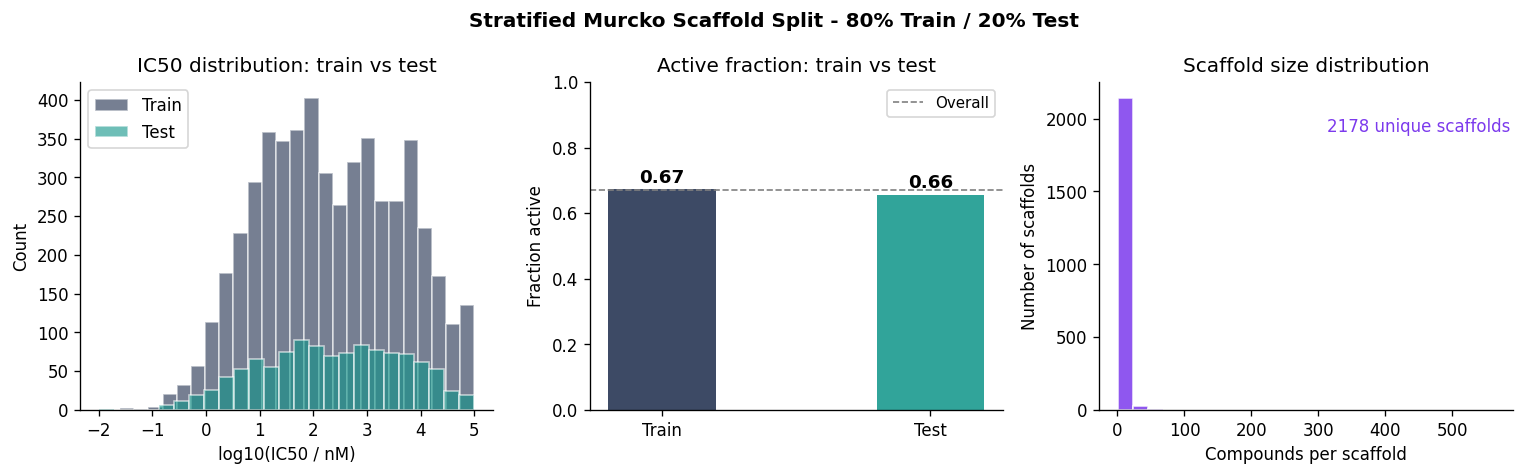

In [ ]:
# Visualize the split
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# IC50 distributions
for split_df, label, color in [
    (df_train, 'Train', '#1B2A4A'),
    (df_test,  'Test',  '#0D9488'),
]:
    axes[0].hist(split_df['log_IC50'], bins=25, alpha=0.6,
                 color=color, label=label, edgecolor='white')
axes[0].set(xlabel='log10(IC50 / nM)', ylabel='Count',
            title='IC50 distribution: train vs test')
axes[0].legend()

# Active fractions
splits  = ['Train', 'Test']
actives = [df_train['active'].mean(), df_test['active'].mean()]
bars    = axes[1].bar(splits, actives, color=['#1B2A4A','#0D9488'],
                      alpha=0.85, width=0.4)
axes[1].axhline(df_dedup['active'].mean(), color='gray', ls='--',
                lw=1, label='Overall')
axes[1].set(ylabel='Fraction active',
            title='Active fraction: train vs test', ylim=(0, 1))
axes[1].legend(fontsize=9)
for bar, val in zip(bars, actives):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# Scaffold size distribution
sc_sizes = df_dedup['scaffold'].value_counts()
axes[2].hist(sc_sizes.values, bins=25, color='#7C3AED',
             alpha=0.85, edgecolor='white')
axes[2].set(xlabel='Compounds per scaffold', ylabel='Number of scaffolds',
            title='Scaffold size distribution')
axes[2].text(0.55, 0.85, f'{n_scaffolds} unique scaffolds', transform=axes[2].transAxes, fontsize=10, color='#7C3AED')

fig.suptitle('Stratified Murcko Scaffold Split - 80% Train / 20% Test',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Assemble feature matrices and save

We combine descriptors and fingerprints into one feature matrix per split
and save everything to Drive for Video 4b.

Feature layout (1032 columns total):
- Columns 0-7:    8 physicochemical descriptors (MW, LogP, HBD, HBA, RotB, TPSA, Rings, ArRings)
- Columns 8-1031: 1024 Morgan fingerprint bits

In [ ]:
DESC_COLS = ['MW', 'LogP', 'HBD', 'HBA', 'RotB', 'TPSA', 'Rings', 'ArRings']

# Train feature matrix
fp_train   = np.vstack([morgan_fp(mol) for mol in df_train['mol']])
desc_train = df_train[DESC_COLS].values.astype(np.float32)
X_train    = np.hstack([desc_train, fp_train]).astype(np.float32)

# Test feature matrix
fp_test   = np.vstack([morgan_fp(mol) for mol in df_test['mol']])
desc_test = df_test[DESC_COLS].values.astype(np.float32)
X_test    = np.hstack([desc_test, fp_test]).astype(np.float32)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'  {len(DESC_COLS)} descriptor columns + {fp_train.shape[1]} fingerprint columns')

X_train: (5179, 1032)
X_test:  (1127, 1032)
  8 descriptor columns + 1024 fingerprint columns


In [ ]:
# Save feature matrices
np.save(OUTPUT_DIR + 'X_train.npy', X_train)
np.save(OUTPUT_DIR + 'X_test.npy',  X_test)

# Save labels
y_train = df_train[['molecule_chembl_id','IC50_nM','log_IC50','active']].reset_index(drop=True)
y_test  = df_test[['molecule_chembl_id', 'IC50_nM','log_IC50','active']].reset_index(drop=True)

y_train.to_csv(OUTPUT_DIR + 'y_train.csv', index=False)
y_test.to_csv(OUTPUT_DIR  + 'y_test.csv',  index=False)

# Save feature column names so Video 4b knows the order
col_names = DESC_COLS + [f'fp_{i}' for i in range(1024)]
pd.Series(col_names).to_csv(
    OUTPUT_DIR + 'feature_names.csv', index=False, header=False)

print('Files saved:')
for fname in ['X_train.npy','X_test.npy','y_train.csv','y_test.csv','feature_names.csv']:
    size = os.path.getsize(OUTPUT_DIR + fname)
    print(f'  {fname:25s}  {size/1024:.0f} KB')

print()
print('Dataset summary:')
print(f'  Total unique compounds:  {len(df_dedup)}')
print(f'  Train / Test:            {len(df_train)} / {len(df_test)}')
print(f'  Train active fraction:   {df_train["active"].mean():.2f}')
print(f'  Test  active fraction:   {df_test["active"].mean():.2f}')
print(f'  Features per compound:   {X_train.shape[1]}')
print()
print('Ready for Video 4b modeling.')

Files saved:
  X_train.npy                20878 KB
  X_test.npy                 4543 KB
  y_train.csv                252 KB
  y_test.csv                 55 KB
  feature_names.csv          7 KB

Dataset summary:
  Total unique compounds:  6306
  Train / Test:            5179 / 1127
  Train active fraction:   0.67
  Test  active fraction:   0.66
  Features per compound:   1032

Ready for Video 4b modeling.


---
## Summary

This notebook prepared the EGFR QSAR dataset from scratch:

- **Pulled** the complete EGFR IC50 dataset from ChEMBL
- **Deduplicated** using geometric mean IC50 per compound
- **Computed** 8 physicochemical descriptors and 1024-bit Morgan fingerprints
- **Log-transformed** IC50 for regression modeling
- **Labeled** compounds active/inactive using a 1000 nM threshold
- **Applied** a stratified Murcko scaffold split with zero scaffold overlap
  and balanced active fractions between train and test

**Next:** Video 4b - training XGBoost and PyTorch models on this dataset